Copyright (c) 2025 Mitsuru Ohno  
Use of this source code is governed by a BSD-3-style  
license that can be found in the LICENSE file.  

## 当ノートブックのワークフロー  
複数のデータフレームを横断的に処理する事例。3成分で相互平衡になっている。  
1. 未知の速度定数を含む、csvに書き込んだ反応式を読み込む。  
2. 化学種の濃度の経時変化の実験データを読み込む。初期濃度を変化させた複数の条件での実験結果を用い、全体を最適化できる速度定数を求めることを目標とする。  
2. 化学種ごとの微分型の反応速度式を作成する。速度定数が未知の素反応にはシンボリックな変数が割り振られる、  
3. 作成した微分方程式を、数値解析可能な形式にする  
4.  scipy.optimize.minimizeを使い、化学種ごとの濃度の経時変化が、実験値と近づくように、未知の速度定数を求める。本ノートブックでは、0に近い速度定数を持つ素反応も含まれることを想定し、速度定数を対数処理してから最適化するモード（def run_fitの引数をuse_log_fit=Trueにする）を用いた。  
5. 経時変化を図示する  

残念ながら、df2の結果を再現できていない。複数のデータフレームを横断的に処理する実行例として掲載する。  

## 反応式を記載したcsvファイルを指定する  

In [ ]:
file_path_rxn = './sample_data/ref5/sample_rxn_ref5.csv'  # CSVファイルのパスを指定

In [ ]:
import sys
from pathlib import Path

# examples/ から ../src を sys.path に追加（rxnfit を import するため）
src_path = Path(__file__).resolve().parent.parent / 'src' if '__file__' in dir() else Path('.').resolve().parent / 'src'
sys.path.insert(0, str(src_path))

## 反応速度式をscipy.integrate.solve_ivpで処理できる連立微分方程式にする  

In [ ]:
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from sympy import Symbol
from sympy.core.symbol import Symbol as SympySymbol
import inspect

from rxnfit.build_ode import RxnODEbuild, create_system_rhs
from rxnfit.solv_ode import SolverConfig, RxnODEsolver
from rxnfit.expdata_reader import expdata_read, get_y0_from_expdata
from rxnfit.expdata_fit_sci import ExpDataFitSci

# 反応速度式の作成

In [ ]:
builded_rxnode = RxnODEbuild(file_path_rxn)

In [ ]:
builded_rxnode.get_ode_info(debug_info=True)

In [ ]:
# 作成した微分方程式
builded_rxnode.get_ode_system()[0]

In [ ]:
# 速度定数の確認
print(builded_rxnode.rate_consts_dict)

check_type = [v for v in builded_rxnode.rate_consts_dict.values()]
[type(e) for e in check_type]

## 経時変化の実験データを読み込み　　
### データフレーム化  

In [ ]:
df1 = pd.read_csv(f'./sample_data/ref5/ref5_df1.csv')
df2 = pd.read_csv(f'./sample_data/ref5/ref5_df2.csv')
df3 = pd.read_csv(f'./sample_data/ref5/ref5_df3.csv')
df4 = pd.read_csv(f'./sample_data/ref5/ref5_df4.csv')

# plot_datasets で名前指定する場合、df.attrs['name'] を設定（省略可）
df1.attrs['name'] = 'df1'
df2.attrs['name'] = 'df2'
df3.attrs['name'] = 'df3'
df4.attrs['name'] = 'df4'

expdata_read([df1, df2, df3, df4])  # 複数データフレームのリストを渡すとまとめて読み込み可能

### フィッティング  
ExpDataFitSci でシンボリックな速度定数をフィッティング。  


In [ ]:
builded_rxnode = RxnODEbuild(file_path_rxn)
t_range = (float(df1.iloc[:, 0].min()), float(df1.iloc[:, 0].max()))
fit_sci = ExpDataFitSci(builded_rxnode, [df1, df2, df3, df4], t_range)
result, param_info, fit_metrics = fit_sci.run_fit(
    p0=[1e-6, 1e-6, 1e-1, 1e-1, 1e-1, 1e-1], # 未知の速度定数の初期値  
    use_log_fit=True, # k1, k2が0に近いと予想されるため、対数変換した値でフィットする  
    lower_bound=1e-10,
)  

C:\Users\mt_oh\AppData\Local\Temp\ipykernel_15128\3208552477.py:2: UserWarning: Integration failed for dataset 2.
  fit_sci.plot_fitted_solution(


  Failed DataFrame (dataset 2):
   hr    oXy    mXy    pXy
0   0  0.005  0.986  0.009
1   1  0.006  0.973  0.021
2   2  0.026  0.933  0.041
3   3  0.020  0.918  0.062
4   5  0.046  0.860  0.094

=== Time-course plot ===


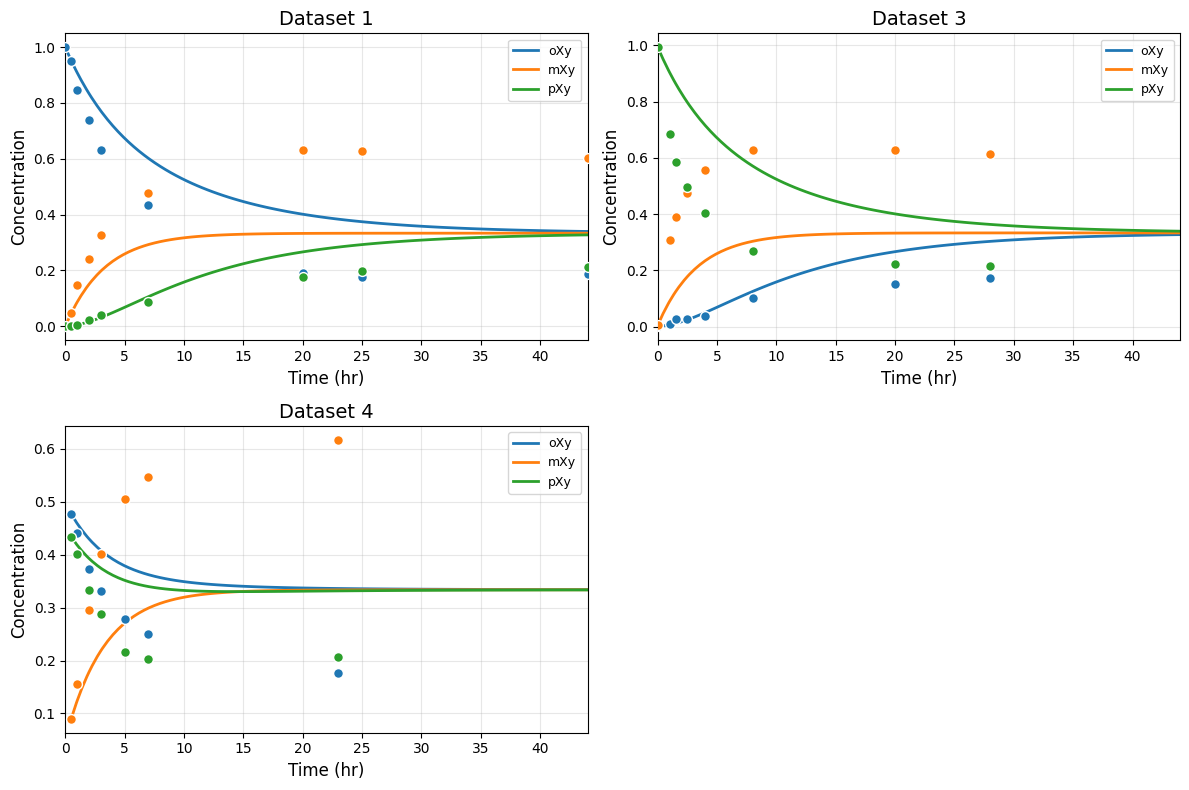


=== Concentration at the final time point ===
Dataset 1:
  oXy: 0.339460
  mXy: 0.333333
  pXy: 0.327208
Dataset 3:
  oXy: 0.326911
  mXy: 0.332999
  pXy: 0.339089
Dataset 4:
  oXy: 0.333944
  mXy: 0.333666
  pXy: 0.333389


In [30]:
# 経時変化を図示（plot_fitted_solution を使用）
fit_sci.plot_fitted_solution(
    expdata_df=[df1, df2, df3, df4], 
    plot_datasets=["df1", "df2", "df3", "df4"], 
    species=['oXy', 'mXy', 'pXy'], 
    subplot_layout=(2,2)
)